In [8]:
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

In [10]:
with open("mutton_biryani.txt", "r", encoding="utf-8") as file:
    original_text = file.read()

print("Original Text:\n")
print(original_text)

Original Text:

Mutton biryani is my favourite food because of its rich aroma and delicious taste.
The tender pieces of mutton blend perfectly with the fragrant basmati rice.
The combination of spices gives every bite a unique and satisfying flavour.
I especially enjoy biryani when it is served hot with onion raita and a boiled egg.
The slow-cooking process allows the flavours of the meat, rice, and spices to blend together.
As a foodie, I enjoy exploring dishes with different flavours, ingredients, and cooking styles.
I appreciate the effort and creativity involved in preparing a delicious meal.
For me, food is not only about satisfying hunger but also about enjoying new tastes and creating memorable experiences.
Among all the dishes I have tasted, mutton biryani will always remain my favourite.




In [18]:
# Divide the original text into sentences

docs = sent_tokenize(original_text)

print("Documents:\n")

for i, document in enumerate(docs, 1):
    print(f"D{i}: {document}")

print(
    "\nTotal Number of Documents:",
    len(docs)
)

Documents:

D1: Mutton biryani is my favourite food because of its rich aroma and delicious taste.
D2: The tender pieces of mutton blend perfectly with the fragrant basmati rice.
D3: The combination of spices gives every bite a unique and satisfying flavour.
D4: I especially enjoy biryani when it is served hot with onion raita and a boiled egg.
D5: The slow-cooking process allows the flavours of the meat, rice, and spices to blend together.
D6: As a foodie, I enjoy exploring dishes with different flavours, ingredients, and cooking styles.
D7: I appreciate the effort and creativity involved in preparing a delicious meal.
D8: For me, food is not only about satisfying hunger but also about enjoying new tastes and creating memorable experiences.
D9: Among all the dishes I have tasted, mutton biryani will always remain my favourite.

Total Number of Documents: 9


In [ ]:
# Define the query
query = "delicious mutton biryani with rice and spices"
print("Query:\n")
print(query)
# Load English stop words
stop_words = set(
    stopwords.words("english")
)

# Create the preprocessing function
def preprocess_text(text):

    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation

    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )
     # Tokenize the text

    words = word_tokenize(text)


    # Remove English stop words

    filtered_words = [
        word
        for word in words
        if word not in stop_words
    ]


    # Join the processed words

    processed_text = " ".join(
        filtered_words
    )


    return processed_text

Query:

delicious mutton biryani with rice and spices


In [20]:
# Preprocess all documents

processed_docs = [
    preprocess_text(document)
    for document in docs
]


# Preprocess the query

processed_query = preprocess_text(
    query
)


# Display processed documents

print("Processed Documents:\n")

for i, document in enumerate(
    processed_docs,
    1
):

    print(
        f"D{i}: {document}"
    )


# Display processed query

print(
    "\nProcessed Query:"
)

print(
    processed_query
)

Processed Documents:

D1: mutton biryani favourite food rich aroma delicious taste
D2: tender pieces mutton blend perfectly fragrant basmati rice
D3: combination spices gives every bite unique satisfying flavour
D4: especially enjoy biryani served hot onion raita boiled egg
D5: slowcooking process allows flavours meat rice spices blend together
D6: foodie enjoy exploring dishes different flavours ingredients cooking styles
D7: appreciate effort creativity involved preparing delicious meal
D8: food satisfying hunger also enjoying new tastes creating memorable experiences
D9: among dishes tasted mutton biryani always remain favourite

Processed Query:
delicious mutton biryani rice spices


In [21]:
# Combine the processed documents and query

all_texts = processed_docs + [
    processed_query
]


print(
    "Number of Documents:",
    len(processed_docs)
)


print(
    "Total Texts Including Query:",
    len(all_texts)
)

Number of Documents: 9
Total Texts Including Query: 10


In [22]:
# Generate labels for all documents

labels = [
    f"D{i}"
    for i in range(
        1,
        len(docs) + 1
    )
]


# Add a label for the query

labels.append(
    "Query"
)


print(
    "Labels:",
    labels
)

Labels: ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'Query']


In [ ]:
# Create the TF-IDF vectorizer

vectorizer = TfidfVectorizer()


# Calculate TF-IDF values

tfidf_matrix = vectorizer.fit_transform(all_texts)


# Convert the sparse matrix into an array

tfidf_array = tfidf_matrix.toarray()


# Get vocabulary terms

feature_names = (vectorizer.get_feature_names_out())


print( "TF-IDF Matrix Shape:",tfidf_array.shape)


print("Number of Vocabulary Terms:",len(feature_names))

TF-IDF Matrix Shape: (10, 62)
Number of Vocabulary Terms: 62


In [24]:
# Create a labelled TF-IDF table

tfidf_table = pd.DataFrame(
    tfidf_array,
    index=labels,
    columns=feature_names
)


# Display the TF-IDF table

display(
    tfidf_table.round(3)
)

,allows,also,always,among,appreciate,aroma,basmati,biryani,bite,blend,...,served,slowcooking,spices,styles,taste,tasted,tastes,tender,together,unique
D1,0.000,0.000,0.000,0.000,0.000,0.413,0.000,0.273,0.000,0.000,...,0.00,0.000,0.000,0.00,0.413,0.000,0.000,0.000,0.000,0.000
D2,0.000,0.000,0.000,0.000,0.000,0.000,0.386,0.000,0.000,0.328,...,0.00,0.000,0.000,0.00,0.000,0.000,0.000,0.386,0.000,0.000
D3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.371,0.000,...,0.00,0.000,0.276,0.00,0.000,0.000,0.000,0.000,0.000,0.371
D4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.231,0.000,0.000,...,0.35,0.000,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.000
D5,0.364,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.309,...,0.00,0.364,0.271,0.00,0.000,0.000,0.000,0.000,0.364,0.000
D6,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.00,0.000,0.000,0.35,0.000,0.000,0.000,0.000,0.000,0.000
D7,0.000,0.000,0.000,0.000,0.391,0.000,0.000,0.000,0.000,0.000,...,0.00,0.000,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.000
D8,0.000,0.325,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.00,0.000,0.000,0.00,0.000,0.000,0.325,0.000,0.000,0.000
D9,0.000,0.000,0.398,0.398,0.000,0.000,0.000,0.263,0.000,0.000,...,0.00,0.000,0.000,0.00,0.000,0.398,0.000,0.000,0.000,0.000
Query,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.415,0.000,0.000,...,0.00,0.000,0.467,0.00,0.000,0.000,0.000,0.000,0.000,0.000


In [25]:
# Display only nonzero TF-IDF values

for i, label in enumerate(labels):

    print(
        f"\n{label} TF-IDF Scores:"
    )


    for term, score in zip(
        feature_names,
        tfidf_array[i]
    ):


        if score > 0:

            print(
                f"{term}: {score:.3f}"
            )


D1 TF-IDF Scores:
aroma: 0.413
biryani: 0.273
delicious: 0.307
favourite: 0.351
food: 0.351
mutton: 0.273
rich: 0.413
taste: 0.413

D2 TF-IDF Scores:
basmati: 0.386
blend: 0.328
fragrant: 0.386
mutton: 0.255
perfectly: 0.386
pieces: 0.386
rice: 0.287
tender: 0.386

D3 TF-IDF Scores:
bite: 0.371
combination: 0.371
every: 0.371
flavour: 0.371
gives: 0.371
satisfying: 0.315
spices: 0.276
unique: 0.371

D4 TF-IDF Scores:
biryani: 0.231
boiled: 0.350
egg: 0.350
enjoy: 0.298
especially: 0.350
hot: 0.350
onion: 0.350
raita: 0.350
served: 0.350

D5 TF-IDF Scores:
allows: 0.364
blend: 0.309
flavours: 0.309
meat: 0.364
process: 0.364
rice: 0.271
slowcooking: 0.364
spices: 0.271
together: 0.364

D6 TF-IDF Scores:
cooking: 0.350
different: 0.350
dishes: 0.297
enjoy: 0.297
exploring: 0.350
flavours: 0.297
foodie: 0.350
ingredients: 0.350
styles: 0.350

D7 TF-IDF Scores:
appreciate: 0.391
creativity: 0.391
delicious: 0.291
effort: 0.391
involved: 0.391
meal: 0.391
preparing: 0.391

D8 TF-IDF Scores

In [26]:
# Select all document vectors

doc_vectors = tfidf_array[:-1]


# Select the query vector

query_vector = (
    tfidf_array[-1]
    .reshape(
        1,
        -1
    )
)


print(
    "Document Vector Shape:",
    doc_vectors.shape
)


print(
    "Query Vector Shape:",
    query_vector.shape
)

Document Vector Shape: (9, 62)
Query Vector Shape: (1, 62)


In [34]:
# Calculate cosine similarity

cos_sim = cosine_similarity(
    doc_vectors,
    query_vector
).flatten()


# Display cosine similarity values

print(
    "Cosine Similarities:\n"
)


for i, similarity in enumerate(
    cos_sim,
    1
):

    print(
        f"D{i} vs Query: "
        f"{similarity:.3f}"
    )

Cosine Similarities:

D1 vs Query: 0.370
D2 vs Query: 0.240
D3 vs Query: 0.129
D4 vs Query: 0.096
D5 vs Query: 0.253
D6 vs Query: 0.000
D7 vs Query: 0.136
D8 vs Query: 0.000
D9 vs Query: 0.219


In [28]:
# Create the cosine-similarity table

similarity_table = pd.DataFrame({

    "Document": labels[:-1],

    "Original Sentence": docs,

    "Cosine Similarity": cos_sim

})


# Display the table

display(
    similarity_table.round(3)
)

,Document,Original Sentence,Cosine Similarity
0,D1,Mutton biryani is my favourite food because of...,0.370
1,D2,The tender pieces of mutton blend perfectly wi...,0.240
2,D3,The combination of spices gives every bite a u...,0.129
3,D4,I especially enjoy biryani when it is served h...,0.096
4,D5,The slow-cooking process allows the flavours o...,0.253
5,D6,"As a foodie, I enjoy exploring dishes with dif...",0.000
6,D7,I appreciate the effort and creativity involve...,0.136
7,D8,"For me, food is not only about satisfying hung...",0.000
8,D9,"Among all the dishes I have tasted, mutton bir...",0.219


In [29]:
# Sort documents from highest to lowest similarity

sorted_similarity_table = (
    similarity_table
    .sort_values(
        by="Cosine Similarity",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# Display sorted results

display(
    sorted_similarity_table.round(3)
)

,Document,Original Sentence,Cosine Similarity
0,D1,Mutton biryani is my favourite food because of...,0.370
1,D5,The slow-cooking process allows the flavours o...,0.253
2,D2,The tender pieces of mutton blend perfectly wi...,0.240
3,D9,"Among all the dishes I have tasted, mutton bir...",0.219
4,D7,I appreciate the effort and creativity involve...,0.136
5,D3,The combination of spices gives every bite a u...,0.129
6,D4,I especially enjoy biryani when it is served h...,0.096
7,D6,"As a foodie, I enjoy exploring dishes with dif...",0.000
8,D8,"For me, food is not only about satisfying hung...",0.000


In [30]:
# Find the document with the highest score

most_similar_index = np.argmax(
    cos_sim
)


# Get the highest cosine-similarity score

highest_similarity = cos_sim[
    most_similar_index
]


print(
    "Most Similar Document:\n"
)


print(
    f"D{most_similar_index + 1}: "
    f"{docs[most_similar_index]}"
)


print(
    "\nCosine Similarity Score:",
    round(
        highest_similarity,
        3
    )
)

Most Similar Document:

D1: Mutton biryani is my favourite food because of its rich aroma and delicious taste.

Cosine Similarity Score: 0.37


In [31]:
# Create the PCA model

pca = PCA(
    n_components=2
)


# Convert the TF-IDF vectors into two dimensions

reduced_vectors = pca.fit_transform(
    tfidf_array
)


# Display the PCA values

pca_table = pd.DataFrame(

    reduced_vectors,

    index=labels,

    columns=[
        "PCA Component 1",
        "PCA Component 2"
    ]

)


display(
    pca_table.round(3)
)

,PCA Component 1,PCA Component 2
D1,0.526,-0.311
D2,0.185,0.520
D3,-0.399,0.160
D4,-0.203,-0.336
D5,-0.119,0.640
D6,-0.434,-0.174
D7,0.003,-0.134
D8,-0.401,-0.231
D9,0.372,-0.348
Query,0.470,0.215


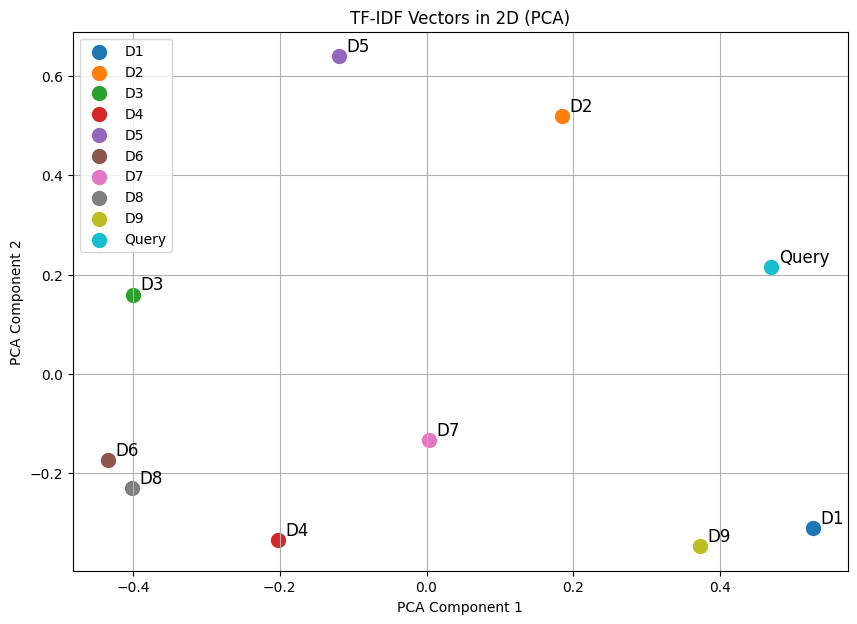

In [32]:
# Create the PCA graph

plt.figure(
    figsize=(10, 7)
)


# Plot documents and query

for i, (x, y) in enumerate(
    reduced_vectors
):

    plt.scatter(
        x,
        y,
        s=100,
        label=labels[i]
    )


    plt.text(
        x + 0.01,
        y + 0.01,
        labels[i],
        fontsize=12
    )


# Add graph details

plt.title(
    "TF-IDF Vectors in 2D (PCA)"
)


plt.xlabel(
    "PCA Component 1"
)


plt.ylabel(
    "PCA Component 2"
)


plt.legend()


plt.grid(
    True
)


# Save the graph

plt.savefig(

    "Screenshots/07_tfidf_vectors_pca.png",

    dpi=300,

    bbox_inches="tight"

)


# Display the graph

plt.show()